<a href="https://colab.research.google.com/github/paulappan/Plant-Disease-Prediction-System/blob/main/Plant_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score




In [ ]:
df=pd.read_csv('/content/plant_disease_combined_50000.csv')
df

,Plant_ID,Plant_Type,Leaf_Color,Leaf_Spot_Size,Humidity,Temperature,Rainfall,Soil_pH,Disease_Status,Disease_Present
0,PLANT_00001,Potato,Brown,7.30,46.33,31.87,3.39,6.72,Healthy,0
1,PLANT_00002,Tomato,Brown,4.45,35.61,19.36,1.60,4.43,Severe Infection,1
2,PLANT_00003,Corn,Brown,6.82,81.99,15.53,14.74,5.30,Healthy,0
3,PLANT_00004,Corn,Yellow,3.00,46.35,29.05,10.48,6.76,Mild Infection,0
4,PLANT_00005,Corn,Green,0.78,74.91,27.58,20.61,4.44,Healthy,0
...,...,...,...,...,...,...,...,...,...,...
49995,PLANT_49996,Rice,Green,1.75,89.90,30.98,8.77,4.71,Severe Infection,0
49996,PLANT_49997,Potato,Brown,2.28,59.77,24.13,5.67,5.07,Healthy,0
49997,PLANT_49998,Corn,Brown,1.94,30.04,25.17,2.60,4.45,Healthy,0
49998,PLANT_49999,Tomato,Green,6.62,32.57,18.49,8.29,4.96,Healthy,0


In [ ]:
df.drop(columns='Plant_ID', inplace=True)

In [ ]:
df['Plant_Type'].unique()

array(['Potato', 'Tomato', 'Corn', 'Rice', 'Wheat'], dtype=object)

In [ ]:
df.isna().sum()

,0
Plant_Type,0
Leaf_Color,0
Leaf_Spot_Size,0
Humidity,0
Temperature,0
Rainfall,0
Soil_pH,0
Disease_Status,0
Disease_Present,0


In [ ]:
df['Plant_Type'].unique()

array(['Potato', 'Tomato', 'Corn', 'Rice', 'Wheat'], dtype=object)

In [ ]:
df['Leaf_Color'].unique()

array(['Brown', 'Yellow', 'Green'], dtype=object)

In [ ]:
df['Temperature'].unique()

array([31.87, 19.36, 15.53, ..., 24.53, 31.52, 27.97])

In [ ]:
df['Humidity'].unique()

array([46.33, 35.61, 81.99, ..., 39.37, 74.88, 76.22])

In [ ]:
df['Rainfall'].unique()

array([ 3.39,  1.6 , 14.74, ..., 32.13, 25.13, 33.28])

In [ ]:
df['Temperature'].unique()

array([31.87, 19.36, 15.53, ..., 24.53, 31.52, 27.97])

In [ ]:
df['Soil_pH'].unique()

array([6.72, 4.43, 5.3 , 6.76, 4.44, 6.27, 4.77, 6.01, 7.88, 8.29, 7.5 ,
       5.56, 7.74, 5.82, 8.06, 4.02, 5.38, 4.99, 6.19, 7.47, 7.89, 8.16,
       5.71, 4.61, 6.74, 6.65, 6.73, 5.74, 8.17, 7.23, 8.37, 4.76, 5.2 ,
       4.86, 4.27, 6.17, 7.86, 5.72, 6.44, 5.68, 8.18, 7.94, 5.16, 7.43,
       6.99, 4.13, 4.57, 5.54, 4.78, 5.06, 6.05, 6.95, 4.83, 6.02, 5.49,
       6.58, 4.4 , 5.01, 8.23, 7.83, 5.4 , 4.49, 7.31, 5.87, 4.85, 7.56,
       5.55, 7.37, 4.12, 6.7 , 5.18, 6.78, 6.26, 6.32, 8.12, 6.35, 4.29,
       7.73, 6.22, 4.14, 5.84, 5.51, 4.93, 4.52, 7.55, 4.92, 7.39, 8.11,
       7.81, 6.92, 7.54, 8.08, 5.65, 7.09, 5.45, 7.52, 4.03, 5.88, 4.19,
       6.55, 4.39, 6.98, 7.01, 6.28, 6.52, 6.56, 6.46, 5.62, 5.86, 6.04,
       7.3 , 7.1 , 8.  , 8.32, 7.95, 6.12, 7.58, 4.84, 7.35, 5.35, 8.25,
       5.43, 4.17, 8.2 , 6.42, 4.09, 7.98, 6.39, 4.41, 5.83, 7.61, 4.28,
       4.56, 5.33, 8.19, 8.35, 8.22, 7.69, 6.15, 5.23, 4.94, 5.13, 6.64,
       6.13, 5.95, 6.62, 4.54, 6.59, 4.58, 8.47, 8.

In [ ]:
df['Disease_Status'].unique()

array(['Healthy', 'Severe Infection', 'Mild Infection'], dtype=object)

In [ ]:

df['Disease_Present'].unique()

array([0, 1])

In [ ]:
encoder1 = LabelEncoder()
encoder2 = LabelEncoder()
encoder3 = LabelEncoder()
encoder_result=LabelEncoder()

In [ ]:
df['Plant_Type'] = encoder1.fit_transform(df['Plant_Type'])
df['Leaf_Color']=encoder2.fit_transform(df['Leaf_Color'])
df['Disease_Status']=encoder3.fit_transform(df['Disease_Status'])


In [ ]:
df

,Plant_Type,Leaf_Color,Leaf_Spot_Size,Humidity,Temperature,Rainfall,Soil_pH,Disease_Status,Disease_Present
0,1,0,7.30,46.33,31.87,3.39,6.72,0,0
1,3,0,4.45,35.61,19.36,1.60,4.43,2,1
2,0,0,6.82,81.99,15.53,14.74,5.30,0,0
3,0,2,3.00,46.35,29.05,10.48,6.76,1,0
4,0,1,0.78,74.91,27.58,20.61,4.44,0,0
...,...,...,...,...,...,...,...,...,...
49995,2,1,1.75,89.90,30.98,8.77,4.71,2,0
49996,1,0,2.28,59.77,24.13,5.67,5.07,0,0
49997,0,0,1.94,30.04,25.17,2.60,4.45,0,0
49998,3,1,6.62,32.57,18.49,8.29,4.96,0,0


In [ ]:
x=df.iloc[:,:-2]

In [ ]:
x

,Plant_Type,Leaf_Color,Leaf_Spot_Size,Humidity,Temperature,Rainfall,Soil_pH
0,1,0,7.30,46.33,31.87,3.39,6.72
1,3,0,4.45,35.61,19.36,1.60,4.43
2,0,0,6.82,81.99,15.53,14.74,5.30
3,0,2,3.00,46.35,29.05,10.48,6.76
4,0,1,0.78,74.91,27.58,20.61,4.44
...,...,...,...,...,...,...,...
49995,2,1,1.75,89.90,30.98,8.77,4.71
49996,1,0,2.28,59.77,24.13,5.67,5.07
49997,0,0,1.94,30.04,25.17,2.60,4.45
49998,3,1,6.62,32.57,18.49,8.29,4.96


In [ ]:
y=df['Disease_Status']

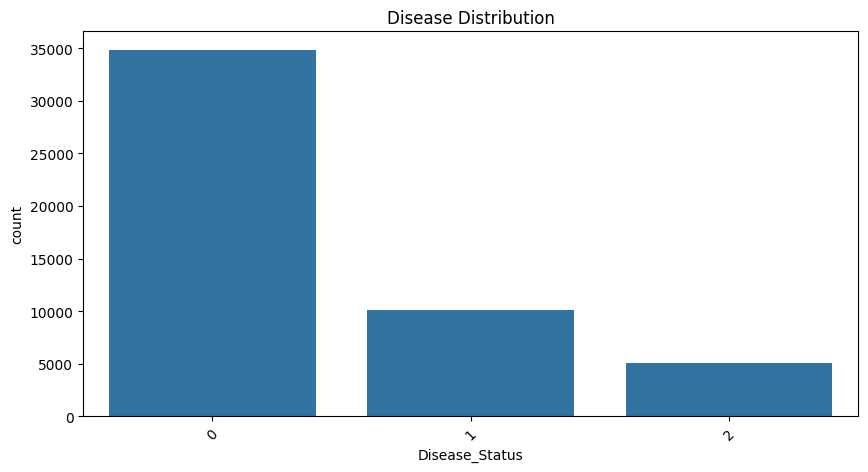

In [ ]:
# DISEASE DISTRIBUTION COUNT PLOT

plt.figure(figsize=(10,5))
sns.countplot(x='Disease_Status', data=df)
plt.xticks(rotation=45)
plt.title('Disease Distribution')
plt.show()

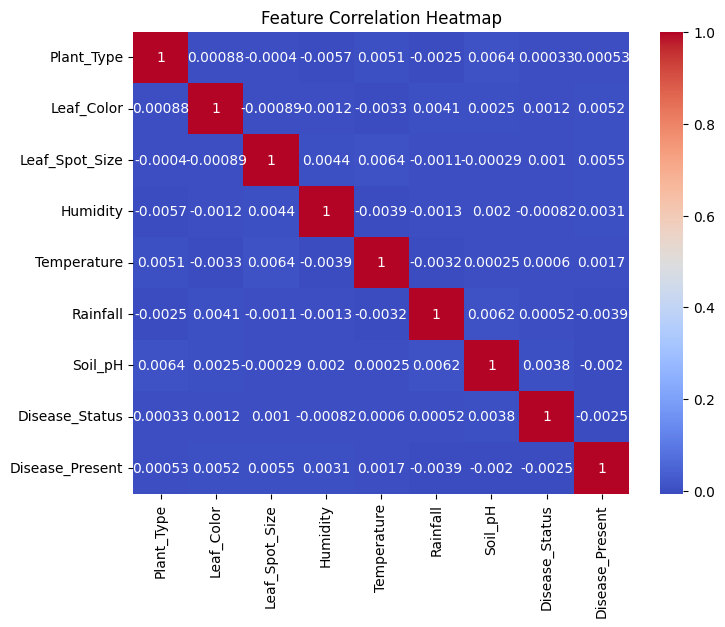

In [ ]:
# CORRELATION HEATMAP

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

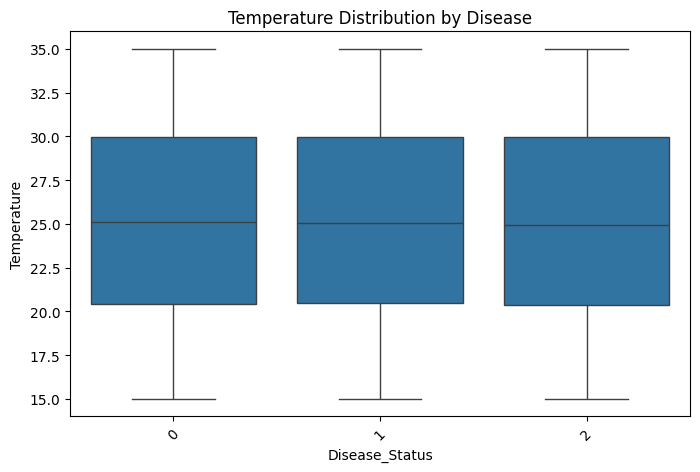

In [ ]:
# TEMPERATURE VS DISEASE

plt.figure(figsize=(8,5))
sns.boxplot(x='Disease_Status', y='Temperature', data=df)
plt.xticks(rotation=45)
plt.title('Temperature Distribution by Disease')
plt.show()

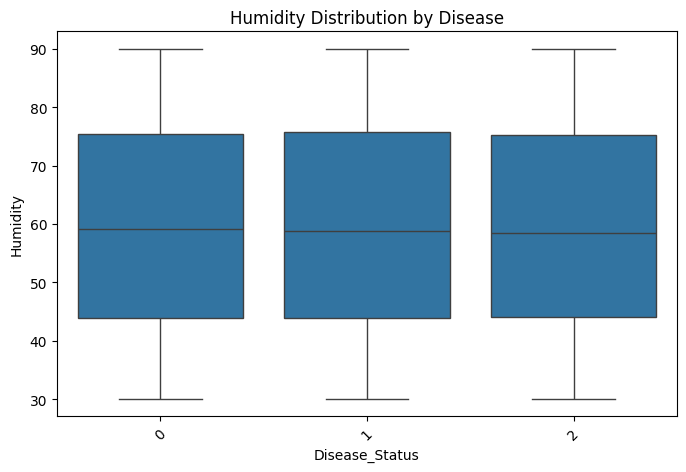

In [ ]:
# HUMIDITY ANALYSIS

plt.figure(figsize=(8,5))
sns.boxplot(x='Disease_Status', y='Humidity', data=df)
plt.xticks(rotation=45)
plt.title('Humidity Distribution by Disease')
plt.show()

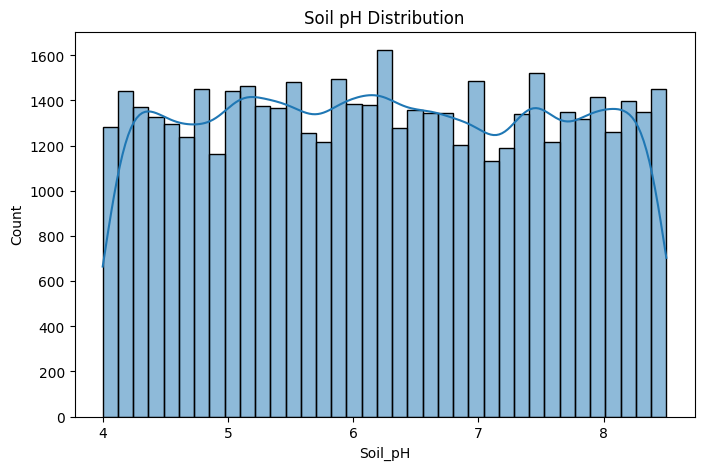

In [ ]:
# SOIL PH DISTRIBUTION

plt.figure(figsize=(8,5))
sns.histplot(df['Soil_pH'], kde=True)
plt.title('Soil pH Distribution')
plt.show()

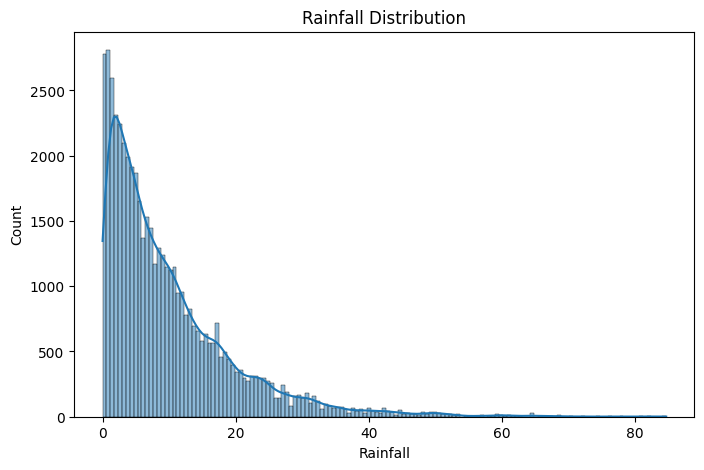

In [ ]:
# RAINFALL DISTRIBUTION

plt.figure(figsize=(8,5))
sns.histplot(df['Rainfall'], kde=True)
plt.title('Rainfall Distribution')
plt.show()

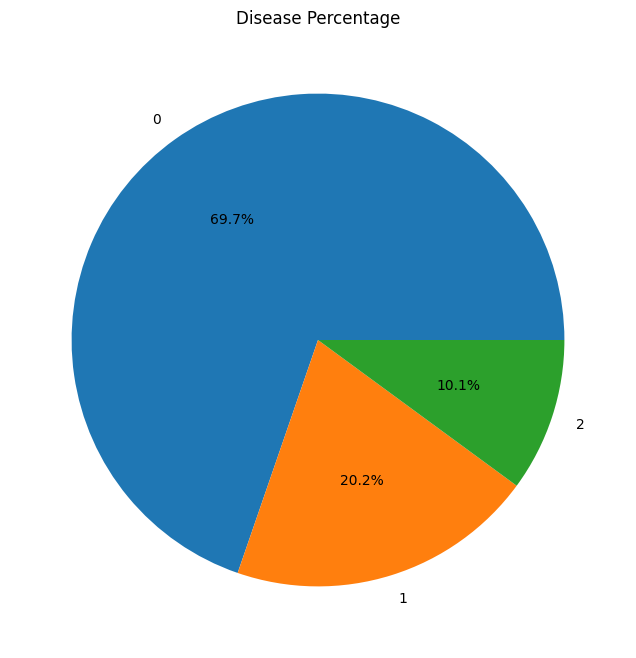

In [ ]:
# DISEASE PERCENTAGE PIE CHART

disease_counts = df['Disease_Status'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    disease_counts,
    labels=disease_counts.index,
    autopct='%1.1f%%'
)
plt.title('Disease Percentage')
plt.show()

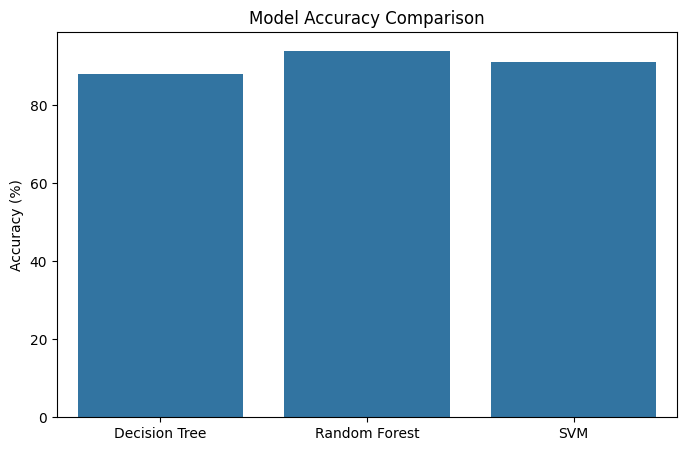

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,      # 80% training, 20% testing
    random_state=42,    # for reproducible results
    stratify=y          # maintains class distribution
)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)

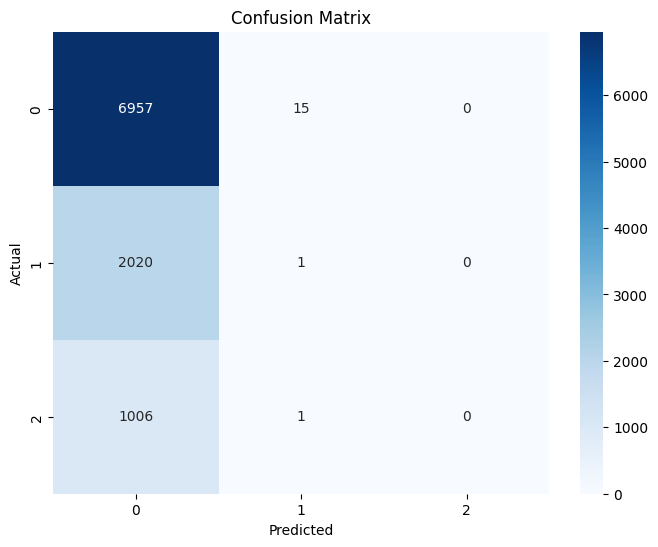

In [ ]:
# CONFUSION MATRIX

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "KNN":
    KNeighborsClassifier(),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Random Forest":
    RandomForestClassifier(),

    "SVM":
    SVC(),

    "Gradient Boosting":
    GradientBoostingClassifier()

}

In [ ]:
results = {}

best_model = None
best_accuracy = 0

for name, model in models.items():

    model.fit(x_train,y_train)

    pred = model.predict(x_test)

    acc = accuracy_score(y_test,pred)

    results[name] = acc

    print(name,acc)

    if acc > best_accuracy:

        best_accuracy = acc

        best_model = model

Logistic Regression 0.6972
KNN 0.6577
Decision Tree 0.5168
Random Forest 0.696
SVM 0.6972
Gradient Boosting 0.697


In [ ]:
# Assuming results dictionary contains model accuracies
best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

print("Models Tested:")
for i, model in enumerate(results.keys(), start=1):
    print(f"{i}. {model}")

print("\nBest Model Selected:")
print(best_model_name)

print("\nAccuracy Achieved:")
print(f"{best_accuracy*100:.2f}%")

# Save the TRAINED MODEL OBJECT
with open("plant_disease_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved successfully!")
print(f"{best_accuracy*100:.2f}%")

Models Tested:
1. Logistic Regression
2. KNN
3. Decision Tree
4. Random Forest
5. SVM
6. Gradient Boosting

Best Model Selected:
Logistic Regression

Accuracy Achieved:
69.72%
Model saved successfully!
69.72%


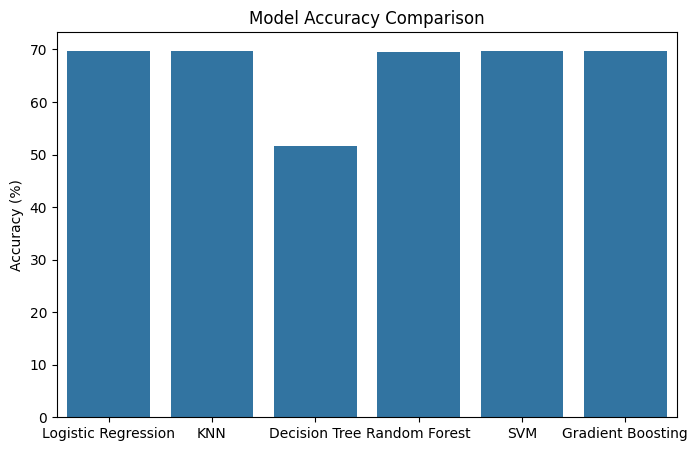

In [ ]:
# MODEL ACCURACY COMPARSION

models = ['Logistic Regression','KNN','Decision Tree','Random Forest','SVM','Gradient Boosting']
accuracy = [69.72,69.77,51.68,69.6,69.72,69.7]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracy)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.show()

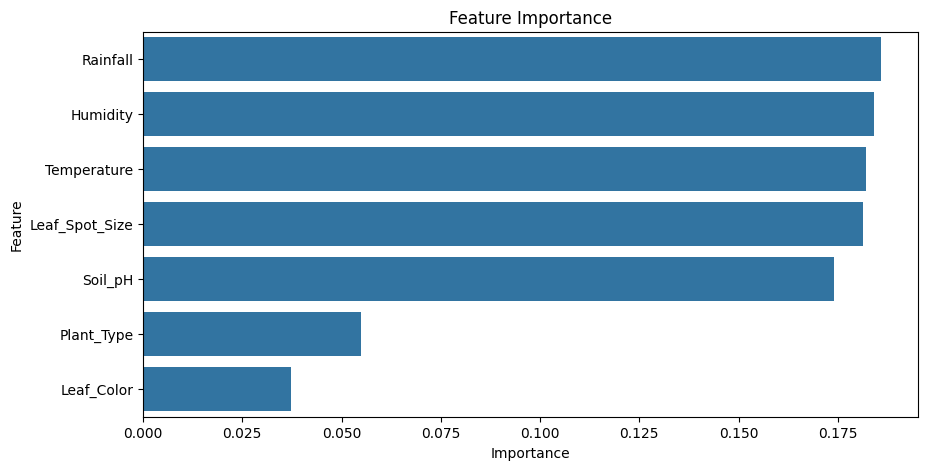

In [ ]:
# FEATURE IMPORTANCE PLOT

model = RandomForestClassifier()
model.fit(x_train, y_train)

importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title('Feature Importance')
plt.show()

In [ ]:
with open("plant_disease_model.pkl","wb") as f:
    pickle.dump(best_model,f)